# Machine Learning 2
## Samuel McAdoo - 100814121 - Final Assignment

In this assignment, I aim to solve captchas using a Machine Learning algorithm. Captchas are small, 5-character long images which are intentionally obfuscated to avoid machine detection. Not so long ago, they were commonplace on the internet to safeguard websites from automation and machines. Due to this, they represent a difficult task which is usually intractable (by definition) to traditional algorithmic approaches.

The Neural Network approach to solving this problem is somewhat complex. I had originally formulated it as a simple classification problem, and had intended to use a YOLO (CNN based) architecture. This proved very ineffective, as I will discuss at more length below, and so I moved to an architecture which utilized attention, which performed much better.


In [1]:
# Cell imports relevant libaries. There are a lot!
import torch
import torchvision
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
import torch.nn.functional as F

import random
import zipfile
from google.colab import files
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import PIL
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split

from torchvision.io import read_image
from torchvision.transforms import Compose, Resize, ToTensor
from torch.utils.data import Dataset, DataLoader

import torch.nn as nn
import torch.nn.functional as F

from sys import getsizeof
from datetime import datetime

device = "cuda" if torch.cuda.is_available() else "cpu"
device

Pretty printing has been turned OFF


'cuda'

# Dataset
The dataset is taken from [Kaggle](https://www.kaggle.com/datasets/parsasam/captcha-dataset). It contains 113,000 images of captchas labeled with their correct solutions.

You can run the cell below, which will prompt you to upload the dataset. Be aware that this can take some time depending on your internet speed, as the dataset is quite large.

I had originally tried to use [this dataset](https://www.kaggle.com/datasets/mrigaankjaswal/capcha-images-to-training-data), but with only 1,070 images it's far too small.

In [2]:
# This will open a picker dialog where you can upload a dataset.
# I have included a dataset with this project, or you can find it on Kaggle
# through the link above.
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
extract_dir = "/content/captcha-dataset"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

image_paths = sorted(
    glob.glob(f"{extract_dir}/**/*.jpg", recursive=True) +
    glob.glob(f"{extract_dir}/**/*.jpeg", recursive=True) +
    glob.glob(f"{extract_dir}/**/*.png", recursive=True)
)

Saving archive (1).zip to archive (1) (1).zip
number of images: 113062
example of one image path: /content/captcha-dataset/111J8.jpg


In [3]:
# Set up domain of the problem.
gt_list = [i[-9:-4] for i in image_paths]
# All chars we have in the sample dataset
# (You can assume safely this is 26 x 2 + 9 = 61 chars, lower, upper, nums)
characters = np.array([list(gt) for gt in gt_list]).flatten()
list_char = sorted(list(set(characters)))
# All CAPTCHAS have 5 chars in them, which is a good advantage for us.
CHAR_PER_LABEL = 5

list_char [np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z')]
len(list_char) 60


In [4]:
def char_to_1_hot(char: str):
    out = np.zeros(len(list_char))
    idx = list_char.index(char)
    out[idx] = 1
    return out


def one_hot(characters: str):
    return np.hstack([char_to_1_hot(c) for c in characters]).astype('uint8')

def one_hot_to_char(x: np.array):
    y = np.array(x)
    y = y.squeeze()
    assert len(y) == len(list_char)
    idx = np.argmax(y)
    return(list_char[idx])


def one_hot_to_label(x):
    y = np.array(x)
    y = y.squeeze()
    label_list = []
    assert len(y) == len(list_char * CHAR_PER_LABEL)
    for i in range(0, CHAR_PER_LABEL):
        start = i * len(list_char)
        end = start + len(list_char)
        label_list.append(one_hot_to_char(y[start: end]))
    return "".join(label_list)

In [ ]:
test_string = "1abDG"
one_hot(test_string)
gt_one_hot = [one_hot(i) for i in gt_list]

In [7]:
class CustomDataset(Dataset):
    def __init__(self, image_paths, gt_one_hot, transform=None):
        self.images_paths = image_paths
        self.gt_list = gt_one_hot
        self.transform = transform

    def __len__(self):
        return len(self.images_paths)

    def __getitem__(self, idx):
        image_path = self.images_paths[idx]
        image = read_image(image_path).to(torch.float)
        label = self.gt_list[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
# Some data transformation takes place here. For example, we make the Captchas
# Grayscale - this gives the CNN less random stuff to focus on, and is a common
# technique for character differentiation, allowing the network to focus on
# edges and features.
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomApply([transforms.RandomRotation(degrees=5)], p=0.5),
    transforms.RandomApply([
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05))
    ], p=0.5),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.3),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
])

transform_val = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
])

transform = transform_val

datasetTrain = CustomDataset(image_paths[:2*len(image_paths)//3], gt_one_hot[:2*len(gt_one_hot)//3], transform=transform_train)
dataloaderTrain = DataLoader(datasetTrain, batch_size=512, shuffle=True)

datasetVal = CustomDataset(image_paths[2*len(image_paths)//3:], gt_one_hot[2*len(gt_one_hot)//3:], transform=transform_val)
dataloaderVal = DataLoader(datasetVal, batch_size=512, shuffle=True)

In [9]:
def my_loss_pytorch(y_pred, y_true, CHAR_PER_LABEL=5, NUM_CHAR=60):
    tot = 0.0
    for i in range(CHAR_PER_LABEL):
        start = i * NUM_CHAR
        end = start + NUM_CHAR

        tot += F.cross_entropy(y_pred[:, start:end], y_true[:, start:end].argmax(dim=1), reduction='sum')
    return tot

# Architecture
### Yolo's Failure
The usage of BiLSTM was motivated primarily by my early failures with YOLO approaches. Because the letters move around in Captcha images, it's very difficult to meaningfully define the anchors such that they actually center around letters; the Captchas are intentionally designed to avoid this. As a result anchor boxes frequently contain either a) no meaningful data (nearly all 0s / white) or multiple letters/numbers chopped in half, or any of a number of things which prevent the YOLO approach from being effective. I was never able to get the YOLO approach to correctly detect the Captcha characters more than about 1-5% of the time. The BiLSTM approach averages around 80% detection rate.

### BiLSTM
As I state above, the motivation for BiLSTM was primarily due to my failure with the YOLO approach. In particular, the finding of correct anchor boxes seemed to me like a fantastic situation with which to implement multi-headed attention. With that in mind, I implemented a CNN architecture which then goes through a 5-headed mutli head attenuation: The idea being that each character can have a head to itself.

This approach ended up proving effective.

![Picture](https://i.imgur.com/LJw99VL.png)

As you can see from the graphic, there are three major stages of the network: First, a CNN layer, which is designed to detect patterns and edges. Secondly, the Bi-directional (thus BI-LSTM) portion, which reads from *both* ends of the source: This will aid in differentiating the individual characters. For example, it would better detect the difference between an M and an N - You can see later on in the results where this can be important. Finally, we flatten the dimensions back down and have a multi-head attention with five heads - one head for each character in every captcha. As I said before, knowing how many characters are in each is a big advantage here!

In [10]:
class GlobalAttention(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Conv2d(num_channels, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.attention(x)


class ModelWithAttentionBiLSTM(nn.Module):
    def __init__(self, num_characters, char_per_label=5, hidden_size=256, num_lstm_layers=2):
        super().__init__()
        self.num_characters = num_characters
        self.char_per_label = char_per_label

        # CNN backbone of the LSTM. Extracts features from the captcha
        # such as lines and other shapes.
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding='same')
        self.bn1   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.bn2   = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding='same')
        self.bn3   = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding='same')
        self.bn4   = nn.BatchNorm2d(512)
        self.pool2 = nn.MaxPool2d((1, 2))

        self.attention = GlobalAttention(512)

        self.height_pool = nn.AdaptiveAvgPool2d((1, None))

        # BiLSTM portion (Read from both sides)
        self.bilstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=num_lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        lstm_out_size = hidden_size * 2

        # Five heads, each predicts one character.
        self.char_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(lstm_out_size, 256),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(256, num_characters)
            )
            for _ in range(char_per_label)
        ])

        self.char_queries = nn.Parameter(torch.randn(char_per_label, lstm_out_size))

    def forward(self, x):
        # CNN
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool2(F.relu(self.bn4(self.conv4(x))))
        x = self.attention(x)

        x = self.height_pool(x).squeeze(2)
        x = x.permute(0, 2, 1)

        # BiLSTM
        lstm_out, _ = self.bilstm(x)

        # 5x Attention heads
        outputs = []
        for i, head in enumerate(self.char_heads):
            query = self.char_queries[i]
            scores = torch.matmul(lstm_out, query)
            weights = torch.softmax(scores, dim=1).unsqueeze(2)
            context = (lstm_out * weights).sum(dim=1)
            outputs.append(head(context))

        return torch.cat(outputs, dim=1)


model = ModelWithAttentionBiLSTM(
    num_characters=len(list_char),
    char_per_label=CHAR_PER_LABEL
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4, amsgrad=True)

In [12]:
model=ModelWithAttentionBiLSTM(60).to(device)
optimizer = torch.optim.AdamW(model.parameters(), 1e-4, amsgrad = True)

# Training

For training, I had some extreme difficulty. Firstly, formulating a good loss f'n for a project such as this is somewhat difficult. Initially, I had formulated a loss f'n based on the amount of white (background) squares vs. the amount of black (character / text) squares that the model was looking at. Basically, asking the machine to 'find' the text in an otherwise white field. This, however, lead to incredibly high loss, with significant issues with the machine finding the gradient; The text was simply too small in the overall sea of background. Additionally, the horizontal lines and artifacting are intentionally placed to make this approach poor. (This is with the YOLO model)

When I implemented the BiLSTM model, it required a different loss as well. This loss was based upon the fact that it needs to output a sequence of characters. Therefore, the loss is calculated to look at the model's ability to predict each position of the CAPTCHA, summing the loss of each position to find the overall loss value. This works much better.

Regarding training, the model was trained on the Google Colab A100 GPU. This is my preferred GPU, and so this project is tuned for that GPU, using datatypes like tf32. 80 Epochs takes around 2 - 2.5 hours on the A100, but would take probably closer to 8-10 hours on a T4. Feasibly, the model's performance could improve with more epochs, but the accuracy the model obtains with 80 (around 75-80% accuracy) is perfectly acceptable, and a good balance between compute expenditure and accuracy.

In [13]:
from tqdm.notebook import tqdm

In [14]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

max_epochs = 80
val_interval = 1
best_val_loss = float('inf')
trainingEpoch_loss = []
trainStepsLoss = []
validationEpoch_loss = []

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=2, eta_min=1e-6
)
scaler = torch.cuda.amp.GradScaler()

def my_loss_pytorch(y_pred, y_true, char_per_label=CHAR_PER_LABEL, num_char=len(list_char)):
    tot = 0.0
    for i in range(char_per_label):
        start = i * num_char
        end   = start + num_char
        tot  += F.cross_entropy(
            y_pred[:, start:end],
            y_true[:, start:end].argmax(dim=1),
            reduction='sum',
            label_smoothing=0.1
        )
    return tot

epoch_bar = tqdm(range(max_epochs), desc="Training", unit="epoch")

for epoch in epoch_bar:
    model.train()
    epoch_loss = 0
    step = 0

    train_bar = tqdm(dataloaderTrain, desc=f"  Epoch {epoch+1:02d} train",
                     leave=False, unit="batch")

    for batch_data in train_bar:
        step += 1
        inputs = batch_data[0].to(device, non_blocking=True)
        labels = batch_data[1].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(inputs)
            loss = my_loss_pytorch(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        trainStepsLoss.append(loss.item())

        train_bar.set_postfix(loss=f"{loss.item():.4f}",
                              lr=f"{scheduler.get_last_lr()[0]:.2e}")

    epoch_loss /= step
    trainingEpoch_loss.append(epoch_loss)
    scheduler.step()

    # Validation step
    if epoch % val_interval == 0:
        model.eval()
        val_loss = 0
        val_steps = 0

        val_bar = tqdm(dataloaderVal, desc=f"  Epoch {epoch+1:02d} val  ",
                       leave=False, unit="batch")

        with torch.no_grad():
            for batch_data in val_bar:
                inputs = batch_data[0].to(device, non_blocking=True)
                labels = batch_data[1].to(device, non_blocking=True)
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    outputs = model(inputs)
                    loss = my_loss_pytorch(outputs, labels)
                val_loss += loss.item()
                val_steps += 1
                val_bar.set_postfix(val_loss=f"{loss.item():.4f}")

        average_val_loss = val_loss / val_steps
        validationEpoch_loss.append(average_val_loss)

        if average_val_loss < best_val_loss:
            best_val_loss = average_val_loss
            torch.save(model.state_dict(), 'model_best.pth')

        epoch_bar.set_postfix(
            train=f"{epoch_loss:.4f}",
            val=f"{average_val_loss:.4f}",
            best=f"{best_val_loss:.4f}",
            saved="✓" if average_val_loss == best_val_loss else " "
        )

/tmp/ipykernel_25904/2142337892.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Training:   0%|          | 0/80 [00:00<?, ?epoch/s]

  Epoch 01 train:   0%|          | 0/148 [00:00<?, ?batch/s]

  Epoch 01 val  :   0%|          | 0/74 [00:00<?, ?batch/s]

  Epoch 02 train:   0%|          | 0/148 [00:00<?, ?batch/s]

...

  Epoch 78 val  :   0%|          | 0/74 [00:00<?, ?batch/s]

  Epoch 79 train:   0%|          | 0/148 [00:00<?, ?batch/s]

  Epoch 79 val  :   0%|          | 0/74 [00:00<?, ?batch/s]

  Epoch 80 train:   0%|          | 0/148 [00:00<?, ?batch/s]

  Epoch 80 val  :   0%|          | 0/74 [00:00<?, ?batch/s]

/tmp/ipykernel_25904/1486237534.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


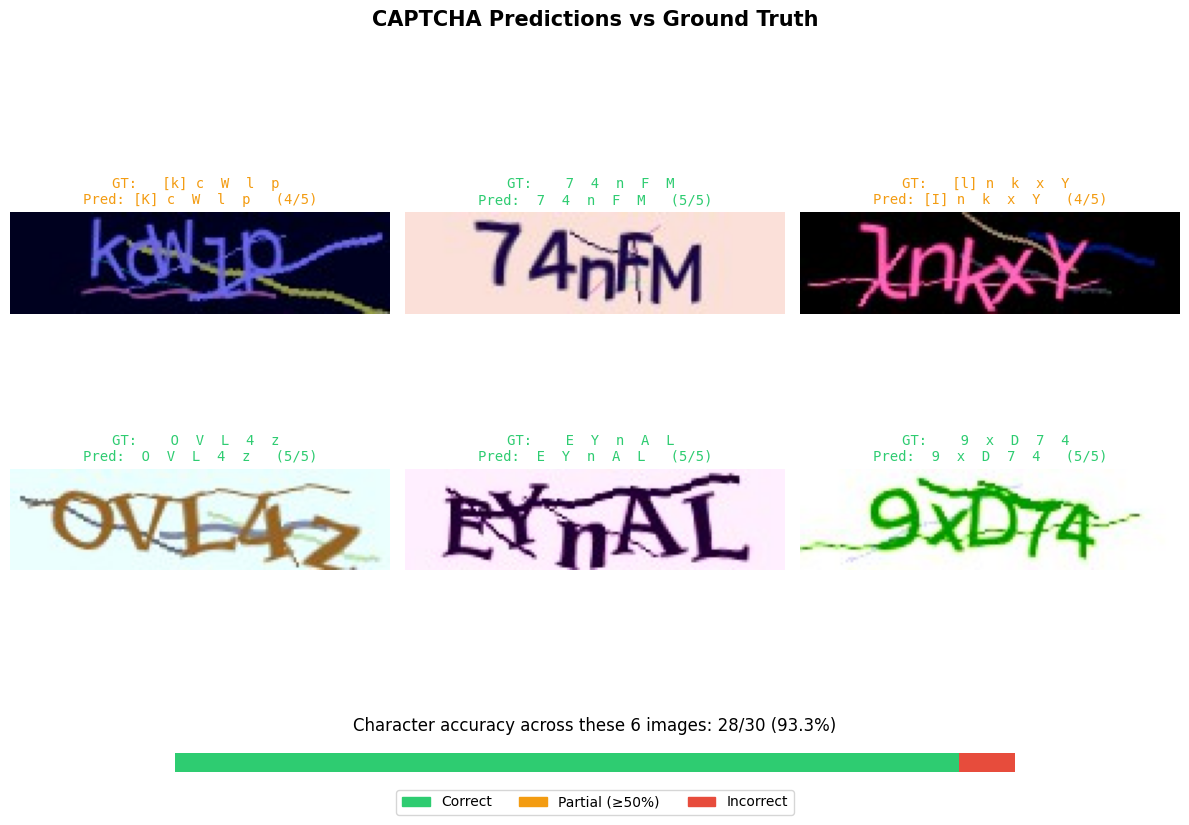

In [42]:
import cv2
import matplotlib.patches as mpatches

model.eval()

N = 6
indices = random.sample(range(len(image_paths)), N)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle("CAPTCHA Predictions vs Ground Truth", fontsize=15, fontweight="bold", y=1.02)

total_chars = 0
correct_chars = 0

for ax, idx in zip(axes.flatten(), indices):
    img_tensor = transform(read_image(image_paths[idx]).to(torch.float))
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))
    prediction = one_hot_to_label(output.cpu().numpy())
    ground_truth = gt_list[idx]

    char_hits = sum(p == g for p, g in zip(prediction, ground_truth))
    total_chars += CHAR_PER_LABEL
    correct_chars += char_hits
    char_acc = char_hits / CHAR_PER_LABEL

    fully_correct = char_hits == CHAR_PER_LABEL
    color = "#2ecc71" if fully_correct else ("#f39c12" if char_acc >= 0.5 else "#e74c3c")

    gt_annotated   = "".join(
        f"[{g}]" if p != g else f" {g} " for p, g in zip(prediction, ground_truth)
    )
    pred_annotated = "".join(
        f"[{p}]" if p != g else f" {p} " for p, g in zip(prediction, ground_truth)
    )

    img_rgb = cv2.cvtColor(cv2.imread(image_paths[idx]), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.axis("off")

    label = f"GT:   {gt_annotated}\nPred: {pred_annotated}  ({char_hits}/{CHAR_PER_LABEL})"
    ax.set_title(label, fontsize=10, color=color, fontfamily="monospace", pad=6)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

fig.text(0.5, -0.01, f"Character accuracy across these 6 images: {correct_chars}/{total_chars} "
         f"({100 * correct_chars / total_chars:.1f}%)", ha="center", fontsize=12)

bar_ax = fig.add_axes([0.15, -0.07, 0.7, 0.03])
bar_ax.barh(0, correct_chars / total_chars, color="#2ecc71", height=1)
bar_ax.barh(0, 1 - correct_chars / total_chars, left=correct_chars / total_chars,
            color="#e74c3c", height=1)
bar_ax.set_xlim(0, 1)
bar_ax.axis("off")

correct_patch = mpatches.Patch(color="#2ecc71", label="Correct")
partial_patch = mpatches.Patch(color="#f39c12", label="Partial (≥50%)")
wrong_patch   = mpatches.Patch(color="#e74c3c", label="Incorrect")
fig.legend(handles=[correct_patch, partial_patch, wrong_patch],
           loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.14))

plt.tight_layout()
plt.show()